In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import numpy as np
import torch
import matplotlib.pyplot as plt

In [ ]:
def _batch_size_from_meta(meta):
    if isinstance(meta, dict):
        for v in meta.values():
            if torch.is_tensor(v):
                return int(v.shape[0])
            if isinstance(v, (list, tuple)):
                return len(v)
        raise ValueError("Could not infer batch size from meta dict.")
    if isinstance(meta, (list, tuple)):
        return len(meta)
    raise ValueError(f"Unsupported meta type: {type(meta)}")


def _meta_at(meta, i):
    if isinstance(meta, dict):
        out = {}
        for k, v in meta.items():
            if torch.is_tensor(v):
                val = v[i]
                out[k] = val.item() if val.ndim == 0 else val.cpu().numpy()
            elif isinstance(v, (list, tuple)):
                out[k] = v[i]
            else:
                out[k] = v
        return out
    elif isinstance(meta, (list, tuple)):
        return meta[i]
    else:
        raise ValueError(f"Unsupported meta type: {type(meta)}")

In [ ]:
def month_to_season(month: int) -> str:
    month = int(month)
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    elif month in [9, 10, 11]:
        return "SON"
    raise ValueError(f"Invalid month: {month}")


def get_scale_token_ranges_from_interpret(interpret):
    return scale_boundaries_from_shapes(interpret["scale_token_shapes"])

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FactorizedSTBlock(nn.Module):
    def __init__(self, d_model, nhead, mlp_ratio=4.0, dropout=0.0, attn_dropout=0.0):
        super().__init__()
        self.ln_s = nn.LayerNorm(d_model)
        self.attn_s = nn.MultiheadAttention(
            d_model, nhead, dropout=attn_dropout, batch_first=True
        )

        self.ln_t = nn.LayerNorm(d_model)
        self.attn_t = nn.MultiheadAttention(
            d_model, nhead, dropout=attn_dropout, batch_first=True
        )

        self.ln_m = nn.LayerNorm(d_model)
        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(
        self,
        x,
        return_attn: bool = False,
        average_attn_weights: bool = False,
    ):
        """
        x: (B, T, N, D)

        return_attn=False:
            기존과 동일하게 x만 반환

        return_attn=True:
            x, aux 반환
            aux = {
                "spatial_attn": (B, T, H, N, N) or (B, T, N, N),
                "temporal_attn": (B, N, H, T, T) or (B, N, T, T),
            }
        """
        B, T, N, D = x.shape
        aux = {}

        # Spatial attention: (B*T, N, D)
        xs = self.ln_s(x).reshape(B * T, N, D)
        if return_attn:
            ys, attn_s = self.attn_s(
                xs, xs, xs,
                need_weights=True,
                average_attn_weights=average_attn_weights,
            )
        else:
            ys, _ = self.attn_s(xs, xs, xs, need_weights=False)

        x = x + ys.reshape(B, T, N, D)

        # Temporal attention: (B*N, T, D)
        xt = self.ln_t(x).permute(0, 2, 1, 3).reshape(B * N, T, D)
        if return_attn:
            yt, attn_t = self.attn_t(
                xt, xt, xt,
                need_weights=True,
                average_attn_weights=average_attn_weights,
            )
        else:
            yt, _ = self.attn_t(xt, xt, xt, need_weights=False)

        x = x + yt.reshape(B, N, T, D).permute(0, 2, 1, 3)

        x = x + self.mlp(self.ln_m(x))

        if return_attn:
            # attn_s:
            # average_attn_weights=False -> (B*T, num_heads, N, N)
            # average_attn_weights=True  -> (B*T, N, N)
            if average_attn_weights:
                attn_s = attn_s.reshape(B, T, N, N)
            else:
                Hh = attn_s.shape[1]
                attn_s = attn_s.reshape(B, T, Hh, N, N)

            # attn_t:
            # average_attn_weights=False -> (B*N, num_heads, T, T)
            # average_attn_weights=True  -> (B*N, T, T)
            if average_attn_weights:
                attn_t = attn_t.reshape(B, N, T, T)
            else:
                Hh = attn_t.shape[1]
                attn_t = attn_t.reshape(B, N, Hh, T, T)

            aux["spatial_attn"] = attn_s.detach()
            aux["temporal_attn"] = attn_t.detach()
            return x, aux

        return x


class MSFormerV3(nn.Module):
    def __init__(
        self,
        image_size=32,
        in_chans=1,
        tin=14,
        tout=7,
        d_model=128,
        depth=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.0,
        attn_dropout=0.0,
        spatial_scales=(2, 4, 8, 16, 32),
        fusion="sum",          # "sum", "gated", "gated2"
        use_pad=True,
        use_pos_emb=False,
        time_pool="last",      # "mean" or "last"
    ):
        super().__init__()
        self.image_size = int(image_size)
        self.in_chans = int(in_chans)
        self.tin = int(tin)
        self.tout = int(tout)
        self.d_model = int(d_model)
        self.depth = int(depth)

        self.scales = tuple(int(s) for s in spatial_scales)
        assert len(self.scales) >= 1
        self.fusion = fusion
        assert self.fusion in ["sum", "gated", "gated2"]
        self.use_pad = bool(use_pad)
        self.use_pos_emb = bool(use_pos_emb)
        self.time_pool = str(time_pool)
        assert self.time_pool in ["mean", "last"]

        self.smoother = nn.Sequential(
            nn.Conv2d(self.in_chans, self.in_chans, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(self.in_chans, self.in_chans, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(self.in_chans, self.in_chans, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(self.in_chans, self.in_chans, kernel_size=3, padding=1),
        )

        self.tokenizers = nn.ModuleDict()
        for s in self.scales:
            self.tokenizers[str(s)] = nn.Conv2d(
                self.in_chans, self.d_model, kernel_size=s, stride=s, bias=True
            )

        self.time_emb = nn.Embedding(self.tin, self.d_model)
        self.scale_emb = nn.Embedding(len(self.scales), self.d_model)

        self.pos_emb = nn.ModuleDict()
        if self.use_pos_emb:
            for s in self.scales:
                gs = self.image_size // s
                Ns = gs * gs
                self.pos_emb[str(s)] = nn.Embedding(Ns, self.d_model)

        self.blocks = nn.ModuleList([
            FactorizedSTBlock(self.d_model, num_heads, mlp_ratio, dropout, attn_dropout)
            for _ in range(depth)
        ])
        self.ln_f = nn.LayerNorm(self.d_model)

        self.future_heads = nn.ModuleDict()
        self.token_to_patch = nn.ModuleDict()
        for s in self.scales:
            self.future_heads[str(s)] = nn.Linear(self.d_model, self.tout * self.d_model)
            self.token_to_patch[str(s)] = nn.Linear(self.d_model, self.in_chans * s * s)

        if self.fusion in ["gated", "gated2"]:
            self.gate = nn.Sequential(
                nn.Linear(self.d_model * len(self.scales), self.d_model),
                nn.GELU(),
                nn.Linear(self.d_model, len(self.scales)),
            )
        else:
            self.gate = None

    def _pad_to_multiple(self, x, multiple: int):
        h, w = x.shape[-2], x.shape[-1]
        pad_h = (multiple - (h % multiple)) % multiple
        pad_w = (multiple - (w % multiple)) % multiple
        if pad_h == 0 and pad_w == 0:
            return x, (0, 0)
        x = F.pad(x, (0, pad_w, 0, pad_h), mode="replicate")
        return x, (pad_h, pad_w)

    def _tokenize_one_scale(self, x_btchw, s: int):
        tok = self.tokenizers[str(s)](x_btchw)
        gh, gw = tok.shape[-2], tok.shape[-1]
        tok = tok.flatten(2).transpose(1, 2)   # (B*T, Ns, D)
        return tok, gh, gw

    def _decode_scale(self, fut, s: int, gh: int, gw: int):
        """
        fut: (B, Tout, Ns, D)
        return: (B, Tout, C, gh*s, gw*s)
        """
        B = fut.shape[0]
        patch_vec = self.token_to_patch[str(s)](fut)  # (B, Tout, Ns, C*s*s)
        patch_vec = patch_vec.reshape(B, self.tout, gh, gw, self.in_chans, s, s)
        patch_vec = patch_vec.permute(0, 1, 4, 2, 5, 3, 6).contiguous()
        y = patch_vec.reshape(B, self.tout, self.in_chans, gh * s, gw * s)
        return y

    def _pool_scale_rep(self, tok):
        # tok: (B, Tin, Ns, D)
        if self.time_pool == "last":
            rep = tok[:, -1].mean(dim=1)   # (B, D)
        else:
            rep = tok.mean(dim=(1, 2))     # (B, D)
        return rep

    def forward(
        self,
        x,
        return_interpret: bool = False,
        return_attn: bool = False,
        attn_layers=None,
        average_attn_weights: bool = True,
    ):
        """
        기본:
            y = model(x)

        해석:
            y, interpret = model(
                x,
                return_interpret=True,
                return_attn=True,
                attn_layers=[-1],   # 예: 마지막 블록만
                average_attn_weights=True,
            )
        """
        B, Tin, C, H, W = x.shape
        assert C == self.in_chans
        assert Tin == self.tin, f"Tin mismatch: got {Tin}, expected {self.tin}"

        if attn_layers is None:
            attn_layers = []
        attn_layers = set([(self.depth + i) if i < 0 else i for i in attn_layers])

        interpret = {} if return_interpret else None

        xt = x.reshape(B * Tin, C, H, W)
        if self.use_pad:
            xt, (pad_h, pad_w) = self._pad_to_multiple(xt, max(self.scales))
        else:
            pad_h, pad_w = 0, 0

        # -------------------------------------------------
        # tokenize + emb
        # -------------------------------------------------
        scale_tokens = []
        scale_meta = []
        t_idx = torch.arange(Tin, device=x.device)

        for sid, s in enumerate(self.scales):
            tok_s, gh, gw = self._tokenize_one_scale(xt, s)
            Ns = gh * gw
            tok_s = tok_s.reshape(B, Tin, Ns, self.d_model)

            tok_s = tok_s + self.time_emb(t_idx).view(1, Tin, 1, self.d_model)
            sid_tensor = torch.tensor(sid, device=x.device)
            tok_s = tok_s + self.scale_emb(sid_tensor).view(1, 1, 1, self.d_model)

            if self.use_pos_emb:
                p_idx = torch.arange(Ns, device=x.device)
                tok_s = tok_s + self.pos_emb[str(s)](p_idx).view(1, 1, Ns, self.d_model)

            scale_tokens.append(tok_s)
            scale_meta.append((s, Ns, gh, gw))

        if return_interpret:
            interpret["scale_token_shapes"] = {
                int(s): (int(B), int(Tin), int(Ns), int(self.d_model))
                for (s, Ns, _, _) in scale_meta
            }

        # -------------------------------------------------
        # pre-transformer gate
        # -------------------------------------------------
        if self.fusion == "gated":
            reps = [self._pool_scale_rep(tok_s) for tok_s in scale_tokens]
            cat = torch.cat(reps, dim=-1)
            w = torch.softmax(self.gate(cat), dim=-1)
        else:
            w = None

        if return_interpret:
            interpret["fusion_mode"] = self.fusion
            if w is not None:
                interpret["scale_weights"] = {
                    int(s): w[:, i].detach().cpu()
                    for i, (s, _, _, _) in enumerate(scale_meta)
                }

        # -------------------------------------------------
        # transformer
        # -------------------------------------------------
        z = torch.cat(scale_tokens, dim=2)  # (B, Tin, N_total, D)
        h = z

        if return_interpret and return_attn:
            interpret["spatial_attn"] = {}
            interpret["temporal_attn"] = {}

        for bi, blk in enumerate(self.blocks):
            if return_interpret and return_attn and (bi in attn_layers):
                h, attn_aux = blk(
                    h,
                    return_attn=True,
                    average_attn_weights=average_attn_weights,
                )
                interpret["spatial_attn"][bi] = attn_aux["spatial_attn"].cpu()
                interpret["temporal_attn"][bi] = attn_aux["temporal_attn"].cpu()
            else:
                h = blk(h)

        h = self.ln_f(h)

        # -------------------------------------------------
        # post-transformer gate
        # -------------------------------------------------
        if self.fusion == "gated2":
            reps_h = []
            cursor = 0
            for _, Ns, _, _ in scale_meta:
                tok_h = h[:, :, cursor:cursor + Ns, :]
                cursor += Ns
                reps_h.append(self._pool_scale_rep(tok_h))

            cat_h = torch.cat(reps_h, dim=-1)
            w = torch.softmax(self.gate(cat_h), dim=-1)

            if return_interpret:
                interpret["scale_weights"] = {
                    int(s): w[:, i].detach().cpu()
                    for i, (s, _, _, _) in enumerate(scale_meta)
                }

        # -------------------------------------------------
        # scale-wise decode
        # -------------------------------------------------
        ys = []
        cursor = 0

        if return_interpret:
            interpret["scale_outputs"] = {}
            interpret["scale_reps"] = {}
            interpret["scale_future_tokens"] = {}

        for i, (s, Ns, gh, gw) in enumerate(scale_meta):
            tok = h[:, :, cursor:cursor + Ns, :]
            cursor += Ns

            rep = tok[:, -1, :, :] if self.time_pool == "last" else tok.mean(dim=1)

            fut = self.future_heads[str(s)](rep).reshape(B, Ns, self.tout, self.d_model)
            fut = fut.permute(0, 2, 1, 3).contiguous()   # (B, Tout, Ns, D)

            y_s = self._decode_scale(fut, s, gh, gw)

            if w is not None:
                y_s = y_s * w[:, i].view(B, 1, 1, 1, 1)

            ys.append(y_s)

            if return_interpret:
                interpret["scale_reps"][int(s)] = rep.detach().cpu()
                interpret["scale_future_tokens"][int(s)] = fut.detach().cpu()
                interpret["scale_outputs"][int(s)] = y_s.detach().cpu()

        y = torch.stack(ys, dim=0).sum(dim=0)

        if return_interpret:
            interpret["pre_smoother"] = y.detach().cpu()

        if self.use_pad and (pad_h > 0 or pad_w > 0):
            y = y[..., :H, :W]

            if return_interpret:
                interpret["pre_smoother"] = interpret["pre_smoother"][..., :H, :W]
                for s in self.scales:
                    interpret["scale_outputs"][int(s)] = interpret["scale_outputs"][int(s)][..., :H, :W]

        # -------------------------------------------------
        # smoother
        # -------------------------------------------------
        B2, T2, C2, H2, W2 = y.shape
        y2 = y.reshape(B2 * T2, C2, H2, W2)
        smooth_delta = self.smoother(y2)
        y2 = y2 + smooth_delta
        y = y2.reshape(B2, T2, C2, H2, W2)

        if return_interpret:
            interpret["smoother_delta"] = smooth_delta.reshape(B2, T2, C2, H2, W2).detach().cpu()
            interpret["post_smoother"] = y.detach().cpu()

        if return_interpret:
            return y, interpret
        return y


class MSFv3(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        kwargs.setdefault("fusion", "sum")
        self.net = MSFormerV3(**kwargs)

    def forward(self, x, **kwargs):
        return self.net(x, **kwargs)


class MSFGv3(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        kwargs["fusion"] = "gated"
        self.net = MSFormerV3(**kwargs)

    def forward(self, x, **kwargs):
        return self.net(x, **kwargs)


class MSFG2v3(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        kwargs["fusion"] = "gated2"
        self.net = MSFormerV3(**kwargs)

    def forward(self, x, **kwargs):
        return self.net(x, **kwargs)

In [ ]:
cfg = {
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    "batch_size": 30,
    "num_workers": 4,
    "eps_mape": 1e-3,

    "data_path": "./data/oisst_ecs_2533_122130.zarr",
    "mask_path": "./data/oisst_spatial_mask_ecs.npy",
    "stats_cache": "./checkpoints/train_stats.json",
    "var_name": "sst",

    "train_start": "1983-01-01",
    "train_end": "2015-12-31",
    "test_start": "2021-01-01",
    "test_end": "2025-12-31",

    "input_len": 14,
    "pred_len": 7,

    "image_size": 32,
    "d_model": 128,
    "depth": 4,
    "num_heads": 4,
    "mlp_ratio": 4.0,
    "dropout": 0.0,
    "attn_dropout": 0.0,
    "spatial_scales": (2, 4, 8, 16),
    "fusion": "sum",
    "use_pad": True,
    "use_pos_emb": False,
    "time_pool": "last",

    "ckpt_path": "./checkpoints/base/msfv3_gdl03.pt",
}

device = torch.device(cfg["device"])
print(device)

cuda


In [ ]:
def scale_boundaries_from_shapes(scale_token_shapes):
    bounds = {}
    cursor = 0
    for s in sorted(scale_token_shapes.keys()):
        _, _, Ns, _ = scale_token_shapes[s]
        bounds[s] = (cursor, cursor + Ns)
        cursor += Ns
    return bounds

MISSING_VALUE = -9.96921e36

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def ensure_5d_batched(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 5:
        return x
    if x.dim() == 4:
        return x.unsqueeze(2)
    raise ValueError(f"Expected 4D/5D batched tensor, got {tuple(x.shape)}")

def ensure_pred_5d(pred: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    if pred.dim() == 5:
        out = pred
    elif pred.dim() == 4:
        out = pred.unsqueeze(2)
    else:
        raise ValueError(f"Expected pred 4D/5D, got {tuple(pred.shape)}")

    if out.shape[:2] != y.shape[:2] or out.shape[-2:] != y.shape[-2:]:
        raise ValueError(f"pred shape mismatch: pred={tuple(out.shape)} vs y={tuple(y.shape)}")
    if out.shape[2] != y.shape[2]:
        raise ValueError(f"channel mismatch: pred C={out.shape[2]} vs y C={y.shape[2]}")
    return out

def denorm(x, mean, std):
    return x * std + mean

def show_sst_grid(
    images,
    titles=None,
    ncols=4,
    figsize=(16, 4),
    vmin=None,
    vmax=None,
    mask=None,
    flipud=True,
    cmap_name="coolwarm",
):
    n = len(images)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    cmap = plt.cm.get_cmap(cmap_name).copy()
    cmap.set_bad(color="black")

    for ax in axes[n:]:
        ax.axis("off")

    for i, img in enumerate(images):
        ax = axes[i]
        arr = np.asarray(img)

        if flipud:
            arr = np.flipud(arr)

        if mask is not None:
            m = np.asarray(mask).astype(bool)
            if flipud:
                m = np.flipud(m)
            arr = np.ma.masked_where(~m, arr)

        im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap, origin="upper")

        if titles is not None:
            ax.set_title(titles[i], fontsize=10)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

def scale_boundaries(scale_meta):
    bounds = {}
    cursor = 0
    for s, info in scale_meta.items():
        Ns = info["Ns"]
        bounds[int(s)] = (cursor, cursor + Ns)
        cursor += Ns
    return bounds

def query_index_from_hw(h, w, gh, gw, H=32, W=32):
    ph = min(int(h * gh / H), gh - 1)
    pw = min(int(w * gw / W), gw - 1)
    return ph * gw + pw

In [ ]:
class OISSTDatasetWithMeta(Dataset):
    def __init__(
        self,
        ds,
        mask: np.ndarray,
        mean: float,
        std: float,
        tin: int = 14,
        tout: int = 7,
        var_name: str = "sst",
    ):
        self.tin = int(tin)
        self.tout = int(tout)
        self.mask = mask.astype(bool)
        self.mean = float(mean)
        self.std = float(std) if float(std) != 0.0 else 1e-12

        arr = ds[var_name].values.astype(np.float32)
        self.arr = arr
        self.time = ds.time.values

        self.T = arr.shape[0]
        self.H = arr.shape[1]
        self.W = arr.shape[2]

        if self.mask.shape != (self.H, self.W):
            raise ValueError(f"mask shape {self.mask.shape} != data spatial shape {(self.H, self.W)}")

        self.n = self.T - self.tin - self.tout + 1
        if self.n <= 0:
            raise ValueError("Not enough timesteps for the requested (tin, tout).")

    def __len__(self):
        return self.n

    def __getitem__(self, idx: int):
        seq = self.arr[idx : idx + self.tin + self.tout]
        x = seq[: self.tin]
        y = seq[self.tin :]

        x = (x - self.mean) / self.std
        y = (y - self.mean) / self.std

        ocean = self.mask[None, :, :]
        x = np.where(ocean, x, 0.0)
        y = np.where(ocean, y, 0.0)

        x = torch.from_numpy(x).unsqueeze(1)
        y = torch.from_numpy(y).unsqueeze(1)

        t_ref = self.time[idx + self.tin]
        t_py = np.datetime_as_string(t_ref, unit="D")
        year, month, day = map(int, t_py.split("-"))

        jan1 = np.datetime64(f"{year}-01-01")
        doy = int((np.datetime64(t_py) - jan1).astype("timedelta64[D]").astype(int)) + 1

        meta = {
            "idx": int(idx),
            "t_ref": t_py,
            "year": int(year),
            "month": int(month),
            "doy": int(doy),
        }
        return x, y, meta

def open_oisst(path: str | Path):
    path = str(path)
    if path.endswith(".zarr"):
        return xr.open_zarr(path)
    return xr.open_dataset(path)

def compute_mean_std_train(ds_train: xr.Dataset, mask: np.ndarray, var_name: str = "sst"):
    arr = ds_train[var_name].values.astype(np.float32)
    valid = np.isfinite(arr) & (arr != MISSING_VALUE)
    valid &= mask[None, :, :]
    x = arr[valid].astype(np.float64)
    return float(x.mean()), float(x.std() + 1e-12)

def build_test_dataset(
    data_path: str | Path,
    mask: np.ndarray,
    tin: int = 14,
    tout: int = 7,
    var_name: str = "sst",
    train_start: str = "1983-01-01",
    train_end: str = "2015-12-31",
    test_start: str = "2021-01-01",
    test_end: str = "2024-12-31",
    stats_cache_json: str | Path | None = None,
):
    mask = mask.astype(bool)
    ds = open_oisst(data_path)
    ds_train = ds.sel(time=slice(train_start, train_end))
    ds_test = ds.sel(time=slice(test_start, test_end))

    mean, std = compute_mean_std_train(ds_train, mask, var_name=var_name)

    if stats_cache_json is not None:
        p = Path(stats_cache_json)
        p.parent.mkdir(parents=True, exist_ok=True)
        with p.open("w", encoding="utf-8") as f:
            json.dump({"mean": mean, "std": std}, f, indent=2)

    test_set = OISSTDatasetWithMeta(
        ds_test, mask, mean, std, tin=tin, tout=tout, var_name=var_name
    )
    torch_mask = torch.from_numpy(mask).bool()
    return test_set, torch_mask, mean, std

In [ ]:
set_seed(cfg["seed"])

mask = np.load(cfg["mask_path"]).astype(bool)
cfg["image_size"] = int(mask.shape[0])

test_set, mask_hw, mean, std = build_test_dataset(
    data_path=cfg["data_path"],
    mask=mask,
    tin=cfg["input_len"],
    tout=cfg["pred_len"],
    var_name=cfg["var_name"],
    train_start=cfg["train_start"],
    train_end=cfg["train_end"],
    test_start=cfg["test_start"],
    test_end=cfg["test_end"],
    stats_cache_json=cfg["stats_cache"],
)

pin = str(cfg["device"]).startswith("cuda")
test_loader = DataLoader(
    test_set,
    batch_size=cfg["batch_size"],
    shuffle=False,
    num_workers=cfg["num_workers"],
    pin_memory=pin,
    persistent_workers=(cfg["num_workers"] > 0),
    drop_last=False,
)

model = MSFv3(
    image_size=cfg["image_size"],
    in_chans=1,
    tin=cfg["input_len"],
    tout=cfg["pred_len"],
    d_model=cfg["d_model"],
    depth=cfg["depth"],
    num_heads=cfg["num_heads"],
    mlp_ratio=cfg["mlp_ratio"],
    dropout=cfg["dropout"],
    attn_dropout=cfg["attn_dropout"],
    spatial_scales=cfg["spatial_scales"],
    fusion=cfg["fusion"],
    use_pad=cfg["use_pad"],
    use_pos_emb=cfg["use_pos_emb"],
    time_pool=cfg["time_pool"],
).to(device)

ckpt = torch.load(cfg["ckpt_path"], map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

mask_hw = mask_hw.to(device)
print("Loaded checkpoint:", cfg["ckpt_path"])

In [61]:

set_seed(cfg["seed"])

mask = np.load(cfg["mask_path"]).astype(bool)
cfg["image_size"] = int(mask.shape[0])

test_set, mask_hw, mean, std = build_test_dataset(
    data_path=cfg["data_path"],
    mask=mask,
    tin=cfg["input_len"],
    tout=cfg["pred_len"],
    var_name=cfg["var_name"],
    train_start=cfg["train_start"],
    train_end=cfg["train_end"],
    test_start=cfg["test_start"],
    test_end=cfg["test_end"],
    stats_cache_json=cfg["stats_cache"],
)

pin = str(cfg["device"]).startswith("cuda")
test_loader = DataLoader(
    test_set,
    batch_size=cfg["batch_size"],
    shuffle=False,
    num_workers=cfg["num_workers"],
    pin_memory=pin,
    persistent_workers=(cfg["num_workers"] > 0),
    drop_last=False,
)

model = MSFv3(
    image_size=cfg["image_size"],
    in_chans=1,
    tin=cfg["input_len"],
    tout=cfg["pred_len"],
    d_model=cfg["d_model"],
    depth=cfg["depth"],
    num_heads=cfg["num_heads"],
    mlp_ratio=cfg["mlp_ratio"],
    dropout=cfg["dropout"],
    attn_dropout=cfg["attn_dropout"],
    spatial_scales=cfg["spatial_scales"],
    fusion=cfg["fusion"],
    use_pad=cfg["use_pad"],
    use_pos_emb=cfg["use_pos_emb"],
    time_pool=cfg["time_pool"],
).to(device)

ckpt = torch.load(cfg["ckpt_path"], map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

mask_hw = mask_hw.to(device)
print("Loaded checkpoint:", cfg["ckpt_path"])


Loaded checkpoint: ./checkpoints/base/msfv3_gdl03.pt


In [ ]:
@torch.no_grad()
def eval_test(model, loader, mask_hw, device, eps_mape=1e-3):
    model.eval()
    sums = {"mse": 0.0, "rmse": 0.0, "mae": 0.0, "mape": 0.0, "r2": 0.0}
    rmse_t_sum = None
    mae_t_sum = None
    n = 0

    for x, y, meta in loader:
        x = ensure_5d_batched(x.to(device, non_blocking=True))
        y = ensure_5d_batched(y.to(device, non_blocking=True))

        pred = model(x)
        pred = ensure_pred_5d(pred, y)

        sums["mse"] += masked_mse(pred, y, mask_hw).item()
        sums["rmse"] += masked_rmse(pred, y, mask_hw).item()
        sums["mae"] += masked_mae(pred, y, mask_hw).item()
        sums["mape"] += masked_mape(pred, y, mask_hw, eps=eps_mape, as_percent=True).item()
        sums["r2"] += masked_r2(pred, y, mask_hw).item()

        rmse_t = masked_rmse_per_t(pred, y, mask_hw).detach().cpu()
        mae_t = masked_mae_per_t(pred, y, mask_hw).detach().cpu()

        if rmse_t_sum is None:
            rmse_t_sum = rmse_t.clone()
            mae_t_sum = mae_t.clone()
        else:
            rmse_t_sum += rmse_t
            mae_t_sum += mae_t
        n += 1

    for k in sums:
        sums[k] /= max(n, 1)

    sums["rmse_t"] = (rmse_t_sum / max(n, 1)).tolist() if rmse_t_sum is not None else None
    sums["mae_t"] = (mae_t_sum / max(n, 1)).tolist() if mae_t_sum is not None else None
    return sums

test_metrics = eval_test(model, test_loader, mask_hw, device, eps_mape=cfg["eps_mape"])
test_metrics

{'mse': 0.011564817249042089,
 'rmse': 0.10471124495150613,
 'mae': 0.07499511576578265,
 'mape': 43.63579044967401,
 'r2': 0.9045392440967872,
 'rmse_t': [0.045251257717609406,
  0.07239583879709244,
  0.09218019247055054,
  0.10709390044212341,
  0.11879132688045502,
  0.12852714955806732,
  0.1364566683769226],
 'mae_t': [0.03187628090381622,
  0.05275933817028999,
  0.0684598758816719,
  0.08028338849544525,
  0.08980019390583038,
  0.09764964133501053,
  0.10413707792758942]}

In [ ]:
@torch.no_grad()
def get_interpret_batch(
    model,
    loader,
    device,
    batch_index=0,
    attn_layers=[-1],
    average_attn_weights=True,
):
    model.eval()
    for bi, (x, y, meta) in enumerate(loader):
        if bi != batch_index:
            continue

        x = ensure_5d_batched(x.to(device, non_blocking=True))
        y = ensure_5d_batched(y.to(device, non_blocking=True))

        pred, interpret = model(
            x,
            return_interpret=True,
            return_attn=True,
            attn_layers=attn_layers,
            average_attn_weights=average_attn_weights,
        )
        pred = ensure_pred_5d(pred, y)

        return {
            "x": x.detach().cpu(),
            "y": y.detach().cpu(),
            "pred": pred.detach().cpu(),
            "meta": meta,
            "interpret": interpret,
        }

    raise IndexError("batch_index out of range")

bundle = get_interpret_batch(
    model=model,
    loader=test_loader,
    device=device,
    batch_index=4,
    attn_layers=[-1],
    average_attn_weights=True,
)

bundle["pred"].shape, bundle["y"].shape

(torch.Size([30, 7, 1, 32, 32]), torch.Size([30, 7, 1, 32, 32]))

In [ ]:
sample_idx = 0
lead_idx = 0

interpret = bundle["interpret"]

gt_img = denorm(bundle["y"][sample_idx, lead_idx, 0], 0, std)
pred_img = denorm(bundle["pred"][sample_idx, lead_idx, 0], 0, std)

scale_imgs = []
titles = []

for s in sorted(interpret["scale_outputs"].keys()):
    img = denorm(interpret["scale_outputs"][s][sample_idx, lead_idx, 0], 0, std)
    scale_imgs.append(img)
    titles.append(f"scale {s}")

vmin = min([gt_img.min(), pred_img.min()] + [img.min() for img in scale_imgs])
vmax = max([gt_img.max(), pred_img.max()] + [img.max() for img in scale_imgs])

mask = np.load(cfg["mask_path"]).astype(bool)

show_sst_grid(
    [gt_img, pred_img] + scale_imgs,
    titles=["GT", "Pred"] + titles,
    ncols=3,
    figsize=(12, 8),
    vmin=vmin,
    vmax=vmax,
    mask=mask,
)

interpret keys: ['scale_token_shapes', 'fusion_mode', 'spatial_attn', 'temporal_attn', 'scale_outputs', 'scale_reps', 'scale_future_tokens', 'pre_smoother', 'smoother_delta', 'post_smoother']
scale keys: dict_keys([2, 4, 8, 16])
attn blocks: dict_keys([3]) dict_keys([3])
scale_token_shapes: {2: (30, 14, 256, 128), 4: (30, 14, 64, 128), 8: (30, 14, 16, 128), 16: (30, 14, 4, 128)}


/tmp/ipykernel_4171448/1187080909.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


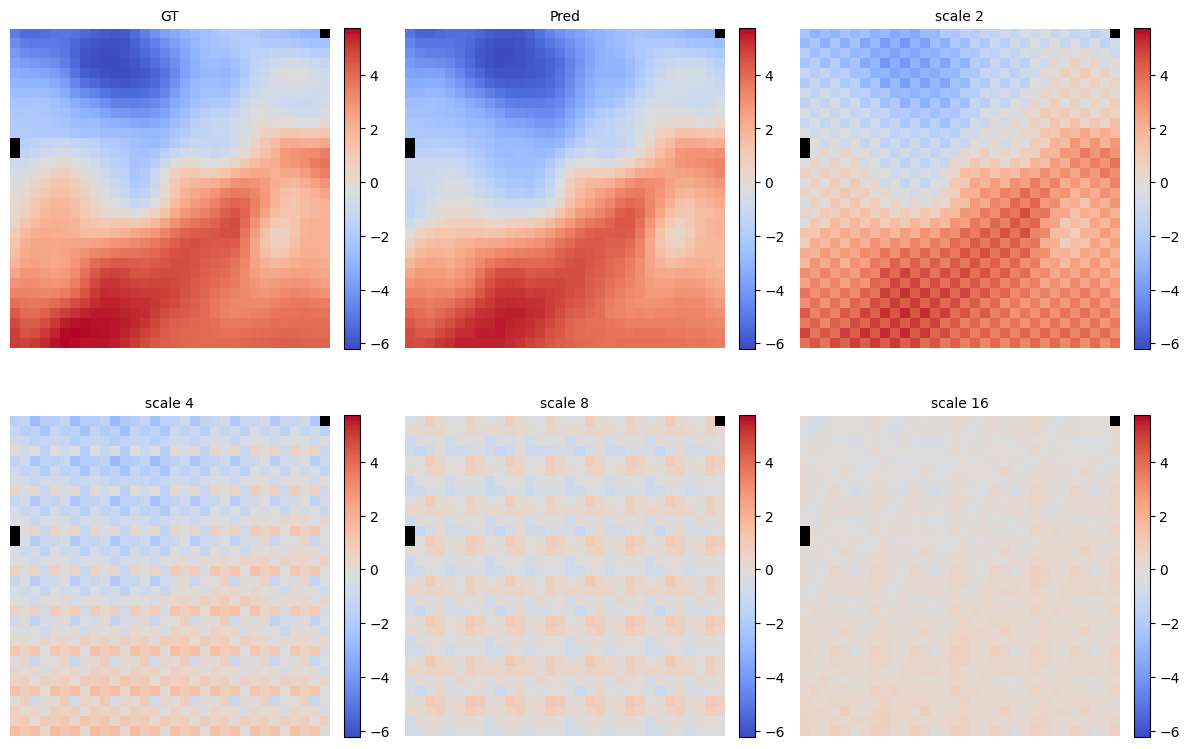

/tmp/ipykernel_4171448/1539124953.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("coolwarm").copy()


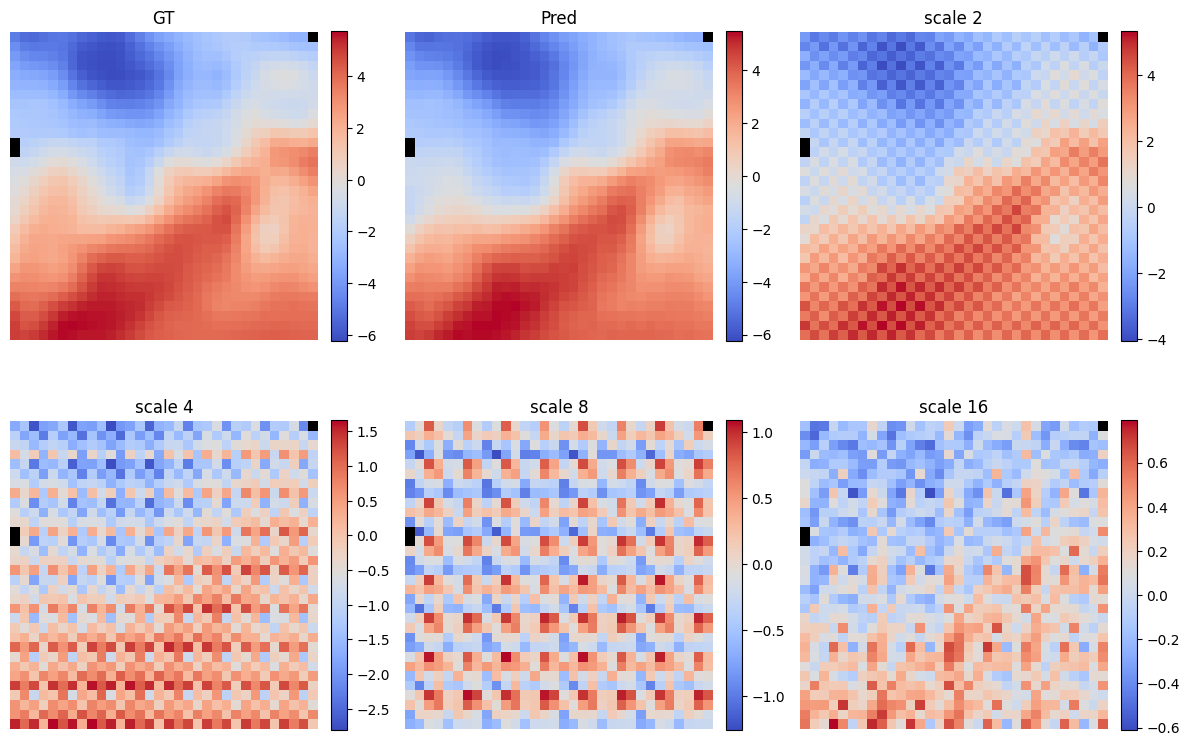

In [ ]:
mask = np.load(cfg["mask_path"]).astype(bool)

imgs = [gt_img, pred_img] + scale_imgs
all_titles = ["GT", "Pred"] + titles

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

cmap = plt.cm.get_cmap("coolwarm").copy()
cmap.set_bad(color="black")

for ax, img, title in zip(axes, imgs, all_titles):
    arr = np.asarray(img)
    arr = np.flipud(arr)
    m = np.flipud(mask)
    arr = np.ma.masked_where(~m, arr)

    im = ax.imshow(arr, cmap=cmap, origin="upper")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4171448/1187080909.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


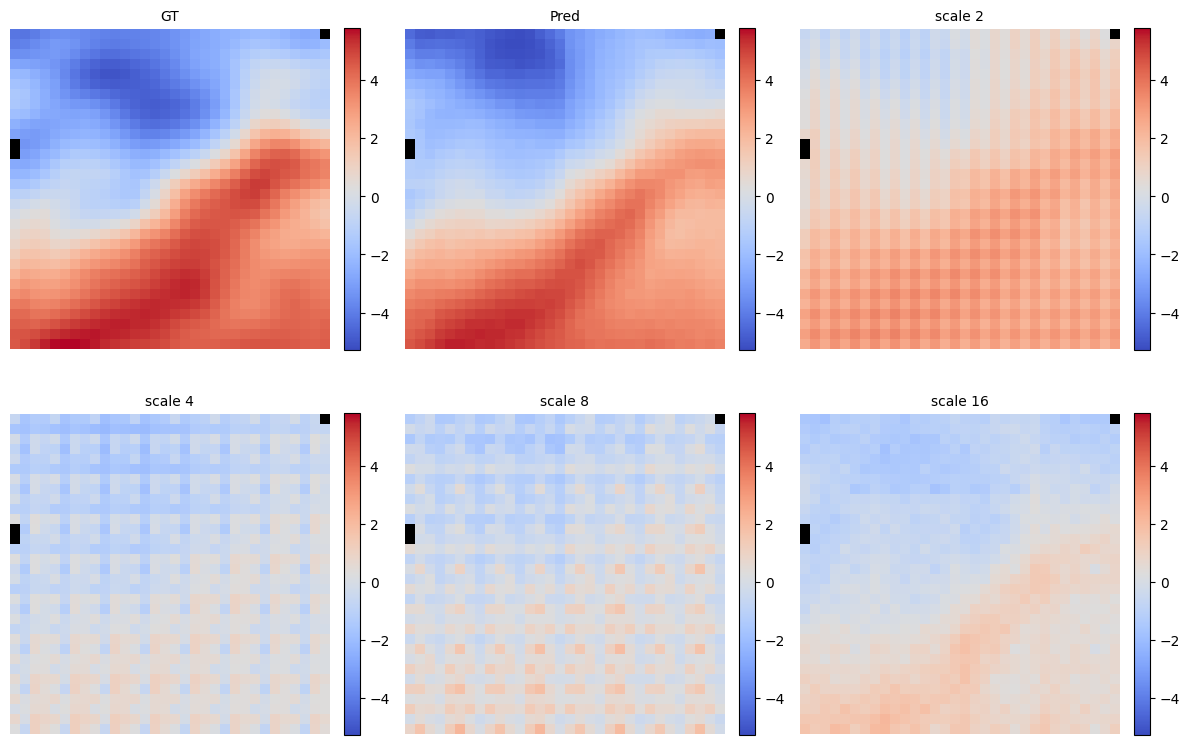

/tmp/ipykernel_4171448/430673216.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("coolwarm").copy()


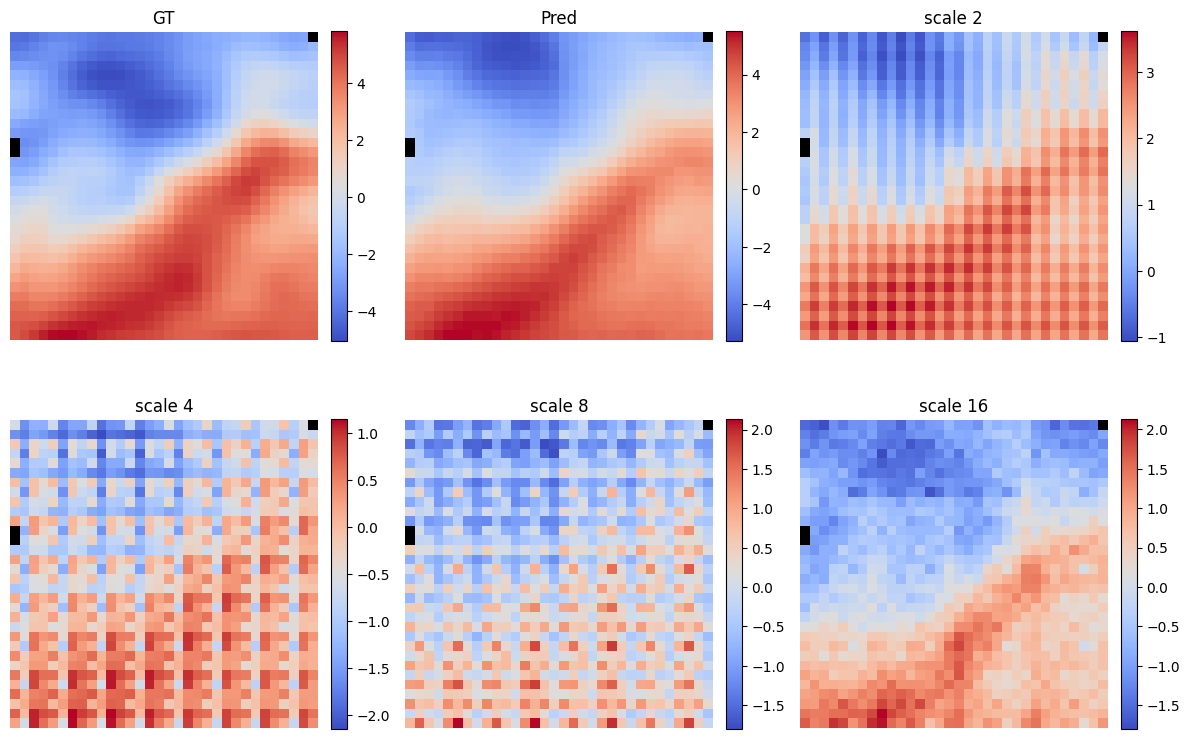

In [66]:

sample_idx = 0
lead_idx = 6

gt_img = denorm(bundle["y"][sample_idx, lead_idx, 0], 0, std)
pred_img = denorm(bundle["pred"][sample_idx, lead_idx, 0], 0, std)

scale_imgs = []
titles = []
for s in sorted(interpret["scale_outputs"].keys()):
    img = denorm(interpret["scale_outputs"][s][sample_idx, lead_idx, 0], 0, std)
    scale_imgs.append(img)
    titles.append(f"scale {s}")

vmin = min([gt_img.min(), pred_img.min()] + [img.min() for img in scale_imgs])
vmax = max([gt_img.max(), pred_img.max()] + [img.max() for img in scale_imgs])


mask = np.load(cfg["mask_path"]).astype(bool)

show_sst_grid(
    [gt_img, pred_img] + scale_imgs,
    titles=["GT", "Pred"] + titles,
    ncols=3,
    figsize=(12, 8),
    vmin=vmin,
    vmax=vmax,
    mask=mask,
)

mask = np.load(cfg["mask_path"]).astype(bool)

imgs = [gt_img, pred_img] + scale_imgs
all_titles = ["GT", "Pred"] + titles

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

cmap = plt.cm.get_cmap("coolwarm").copy()
cmap.set_bad(color="black")

for ax, img, title in zip(axes, imgs, all_titles):
    arr = np.asarray(img)
    arr = np.flipud(arr)                  # 이미지 뒤집기
    m = np.flipud(mask)                   # 마스크도 같이 뒤집기
    arr = np.ma.masked_where(~m, arr)

    im = ax.imshow(arr, cmap=cmap, origin="upper")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4171448/1316159729.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_main = plt.cm.get_cmap("coolwarm").copy()
/tmp/ipykernel_4171448/1316159729.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_scale = plt.cm.get_cmap("coolwarm").copy()


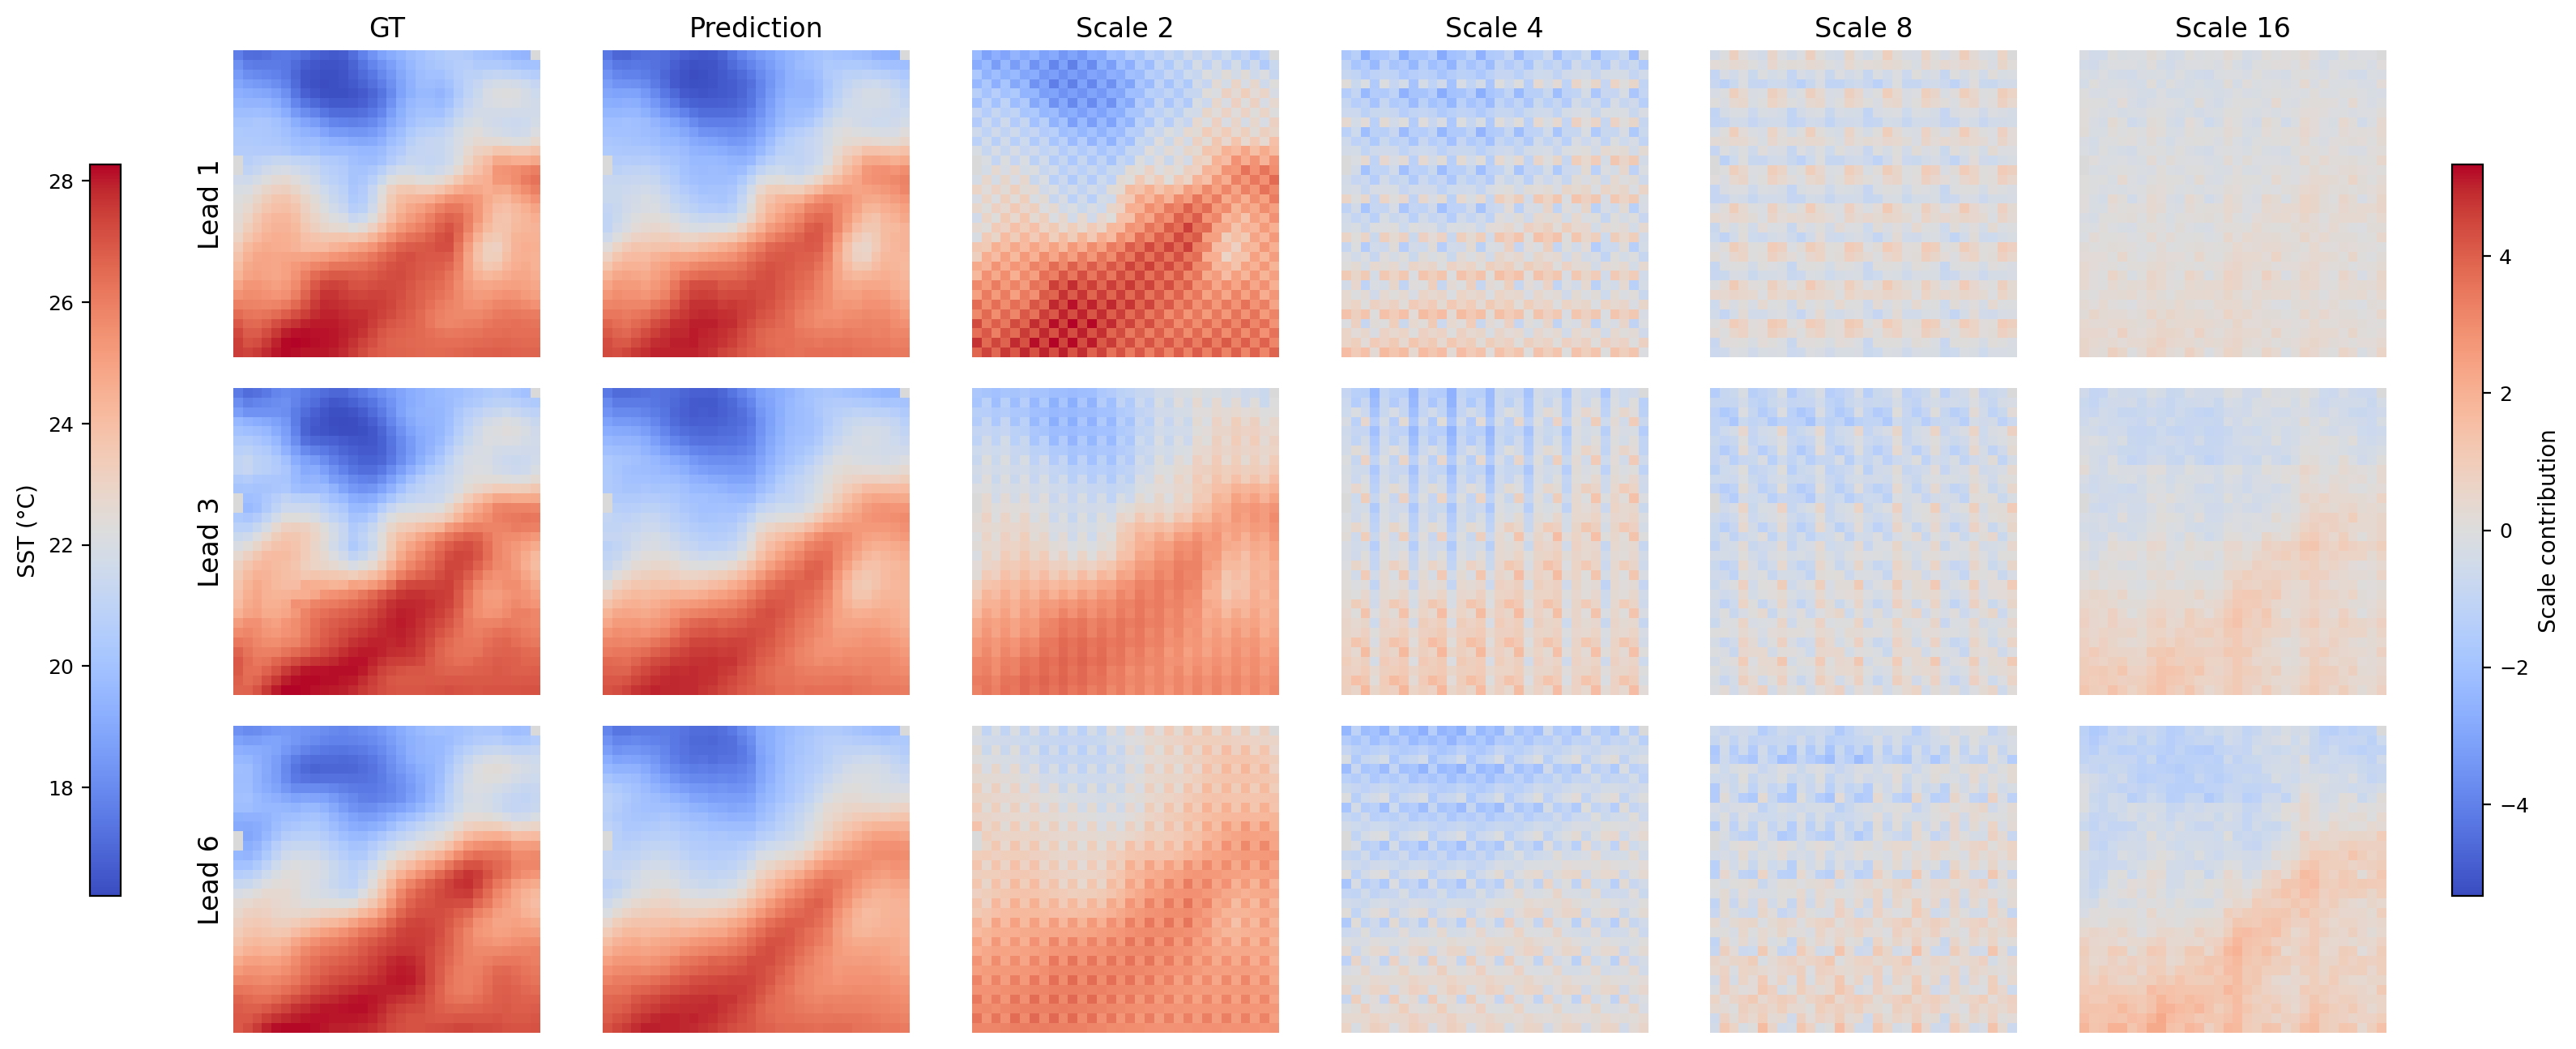

In [67]:
# 논문용 Figure: lead time별(1,3,6일) GT / Pred / scale outputs 비교
# - GT / Prediction: 역정규화(mean, std 적용) + 왼쪽 colorbar
# - Scale outputs: contribution(std만 곱함) + 오른쪽 colorbar
# - mask 영역은 연한 갈색 처리
# - 저장은 포함하지 않음

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 설정
# -----------------------------
sample_idx = 0
lead_list = [0, 2, 5]   # t+1, t+3, t+6
scale_keys = sorted(interpret["scale_outputs"].keys())

mean = 22.5081844329834
std  = 4.8933515548706055

mask = np.load(cfg["mask_path"]).astype(bool)

mask_color = "#d9d9d9"

cmap_main = plt.cm.get_cmap("coolwarm").copy()
cmap_main.set_bad(color=mask_color)

cmap_scale = plt.cm.get_cmap("coolwarm").copy()
cmap_scale.set_bad(color=mask_color)

# -----------------------------
# 범위 계산
# -----------------------------
main_imgs = []
scale_imgs_all = []

for lead_idx in lead_list:
    gt_img = denorm(bundle["y"][sample_idx, lead_idx, 0], mean, std)
    pred_img = denorm(bundle["pred"][sample_idx, lead_idx, 0], mean, std)

    gt_img = np.asarray(gt_img)
    pred_img = np.asarray(pred_img)
    main_imgs.extend([gt_img, pred_img])

    for s in scale_keys:
        sc = interpret["scale_outputs"][s][sample_idx, lead_idx, 0].detach().cpu().numpy()
        sc = sc * std
        scale_imgs_all.append(sc)

main_vmin = min(np.nanmin(img) for img in main_imgs)
main_vmax = max(np.nanmax(img) for img in main_imgs)

scale_abs = max(
    abs(min(np.nanmin(img) for img in scale_imgs_all)),
    abs(max(np.nanmax(img) for img in scale_imgs_all))
)
scale_vmin, scale_vmax = -scale_abs, scale_abs

# -----------------------------
# Figure 생성
# -----------------------------
nrows = len(lead_list)
ncols = 2 + len(scale_keys)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(2.7 * ncols, 2.35 * nrows),
    dpi=200
)

if nrows == 1:
    axes = axes[None, :]

im_main = None
im_scale = None

col_titles = ["GT", "Prediction"] + [f"Scale {s}" for s in scale_keys]

for row, lead_idx in enumerate(lead_list):
    gt_img = denorm(bundle["y"][sample_idx, lead_idx, 0], mean, std)
    pred_img = denorm(bundle["pred"][sample_idx, lead_idx, 0], mean, std)

    row_imgs = [np.asarray(gt_img), np.asarray(pred_img)]
    for s in scale_keys:
        sc = interpret["scale_outputs"][s][sample_idx, lead_idx, 0].detach().cpu().numpy()
        sc = sc * std
        row_imgs.append(sc)

    for col, (ax, img) in enumerate(zip(axes[row], row_imgs)):
        arr = np.asarray(img)
        arr = np.flipud(arr)
        m = np.flipud(mask)
        arr = np.ma.masked_where(~m, arr)

        if col < 2:
            im_main = ax.imshow(
                arr,
                cmap=cmap_main,
                origin="upper",
                vmin=main_vmin,
                vmax=main_vmax,
                interpolation="nearest"
            )
        else:
            im_scale = ax.imshow(
                arr,
                cmap=cmap_scale,
                origin="upper",
                vmin=scale_vmin,
                vmax=scale_vmax,
                interpolation="nearest"
            )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

        if row == 0:
            ax.set_title(col_titles[col], fontsize=12, pad=6)

        if col == 0:
            ax.set_ylabel(
                f"Lead {lead_idx + 1}",
                fontsize=12,
                rotation=90,
                labelpad=10,
                va="center"
            )

# -----------------------------
# 좌/우 colorbar
# -----------------------------
fig.subplots_adjust(
    left=0.08,
    right=0.92,
    top=0.92,
    bottom=0.06,
    wspace=0.03,
    hspace=0.10
)

cax_left = fig.add_axes([0.035, 0.18, 0.012, 0.64])
cbar_left = fig.colorbar(im_main, cax=cax_left)
cbar_left.set_label("SST (°C)", fontsize=10)
cbar_left.ax.tick_params(labelsize=9)
cbar_left.ax.yaxis.set_label_position("left")
cbar_left.ax.yaxis.tick_left()

cax_right = fig.add_axes([0.935, 0.18, 0.012, 0.64])
cbar_right = fig.colorbar(im_scale, cax=cax_right)
cbar_right.set_label("Scale contribution", fontsize=10)
cbar_right.ax.tick_params(labelsize=9)

plt.show()

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def plot_scale_contribution_by_lead(interpret, sample_idx=0):
    scales = sorted(interpret["scale_outputs"].keys())
    lead_count = interpret["scale_outputs"][scales[0]].shape[1]
    leads = np.arange(1, lead_count + 1)

    mean_abs_dict = {s: [] for s in scales}
    std_dict = {s: [] for s in scales}

    for lead_idx in range(lead_count):
        for s in scales:
            y_s = interpret["scale_outputs"][s][sample_idx, lead_idx, 0].detach().cpu().numpy()
            mean_abs_dict[s].append(np.mean(np.abs(y_s)))
            std_dict[s].append(np.std(y_s))

    # 1) mean(abs(y_s)) 그래프
    plt.figure(figsize=(8, 5))
    for s in scales:
        plt.plot(leads, mean_abs_dict[s], marker='o', label=f'scale {s}')
    plt.xlabel("Lead time")
    plt.ylabel("Mean(|y_s|)")
    plt.title(f"Scale contribution magnitude by lead time (sample {sample_idx})")
    plt.xticks(leads)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.ylim(0, 1.0)
    plt.show()

    # 2) std(y_s) 그래프
    plt.figure(figsize=(8, 5))
    for s in scales:
        plt.plot(leads, std_dict[s], marker='o', label=f'scale {s}')
    plt.xlabel("Lead time")
    plt.ylabel("Std(y_s)")
    plt.title(f"Spatial variation by lead time (sample {sample_idx})")
    plt.xticks(leads)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.ylim(0, 0.5)
    plt.show()

    return mean_abs_dict, std_dict

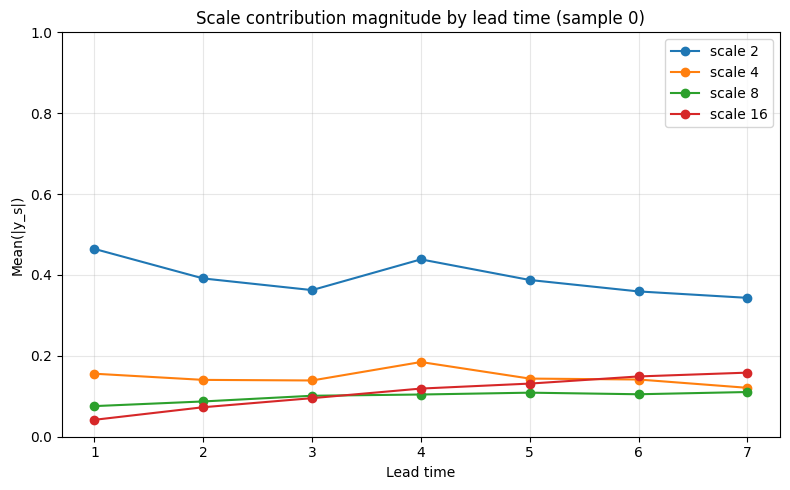

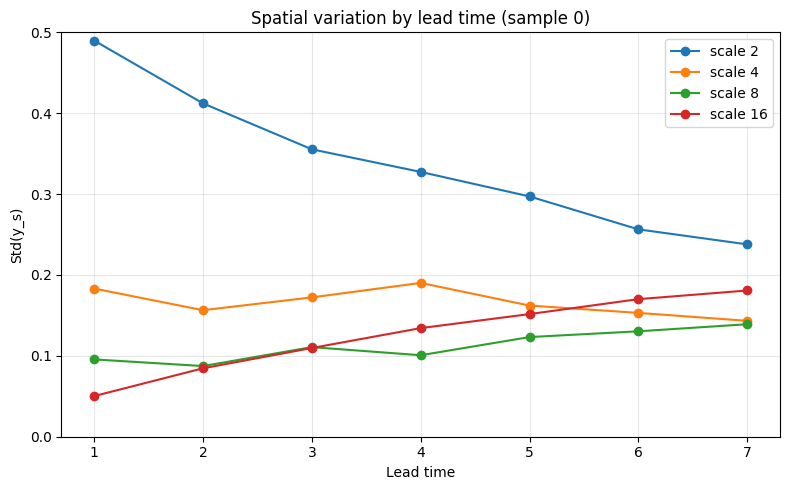

In [69]:
mean_abs_dict, std_dict = plot_scale_contribution_by_lead(interpret, sample_idx=0)

In [70]:
import numpy as np
import matplotlib.pyplot as plt

def plot_dataset_scale_contribution_by_lead(interpret):
    scales = sorted(interpret["scale_outputs"].keys())
    arr0 = interpret["scale_outputs"][scales[0]]
    n_samples, lead_count = arr0.shape[0], arr0.shape[1]
    leads = np.arange(1, lead_count + 1)

    mean_abs_dict = {s: [] for s in scales}
    std_dict = {s: [] for s in scales}
    ratio_dict = {s: [] for s in scales}

    for lead_idx in range(lead_count):
        scale_mean_abs_this_lead = []

        # 먼저 각 scale의 dataset 평균 mean(abs(y_s)) 계산
        for s in scales:
            y = interpret["scale_outputs"][s][:, lead_idx, 0]   # (N, H, W)
            if hasattr(y, "detach"):
                y = y.detach().cpu().numpy()

            # sample별 mean(abs(.))
            sample_mean_abs = np.mean(np.abs(y), axis=(1, 2))   # (N,)
            # sample별 std(.)
            sample_std = np.std(y, axis=(1, 2))                 # (N,)

            mean_abs_avg = sample_mean_abs.mean()
            std_avg = sample_std.mean()

            mean_abs_dict[s].append(mean_abs_avg)
            std_dict[s].append(std_avg)
            scale_mean_abs_this_lead.append(mean_abs_avg)

        # ratio 계산
        scale_mean_abs_this_lead = np.array(scale_mean_abs_this_lead, dtype=np.float64)
        ratios = scale_mean_abs_this_lead / (scale_mean_abs_this_lead.sum() + 1e-12)

        for i, s in enumerate(scales):
            ratio_dict[s].append(ratios[i])

    # ---------------------------
    # 1) mean(abs(y_s))
    # ---------------------------
    plt.figure(figsize=(8, 5))
    for s in scales:
        plt.plot(leads, mean_abs_dict[s], marker='o', label=f'scale {s}')
    plt.xlabel("Lead time")
    plt.ylabel("Dataset-avg Mean(|y_s|)")
    plt.title("Scale contribution magnitude by lead time (dataset average)")
    plt.xticks(leads)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.ylim(0, 1.0)
    plt.show()

    # ---------------------------
    # 3) std(y_s)
    # ---------------------------
    plt.figure(figsize=(8, 5))
    for s in scales:
        plt.plot(leads, std_dict[s], marker='o', label=f'scale {s}')
    plt.xlabel("Lead time")
    plt.ylabel("Dataset-avg Std(y_s)")
    plt.title("Spatial variation by lead time (dataset average)")
    plt.xticks(leads)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.ylim(0, 0.5)
    plt.show()

    return mean_abs_dict, ratio_dict, std_dict

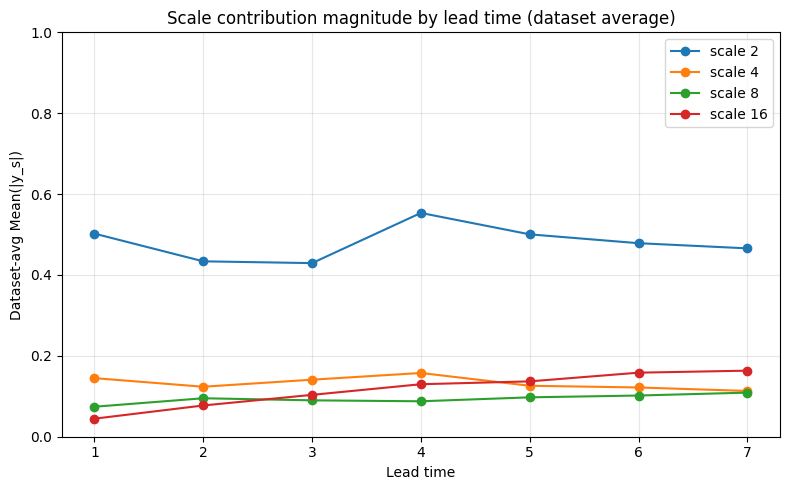

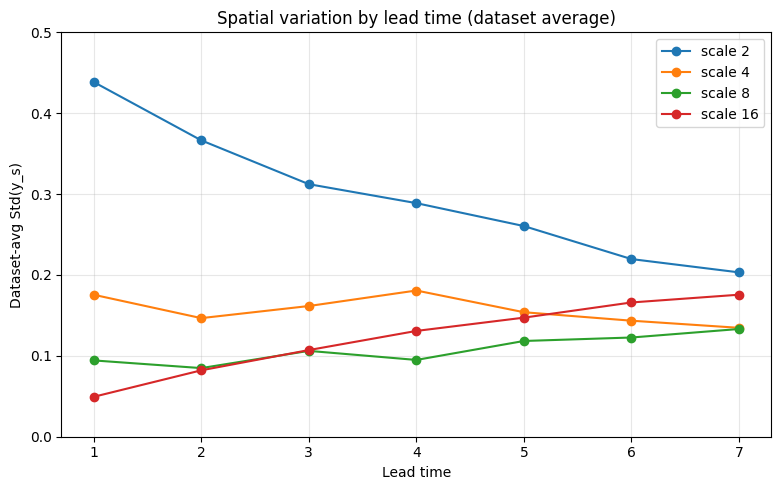

In [71]:
mean_abs_dict, ratio_dict, std_dict = plot_dataset_scale_contribution_by_lead(interpret)

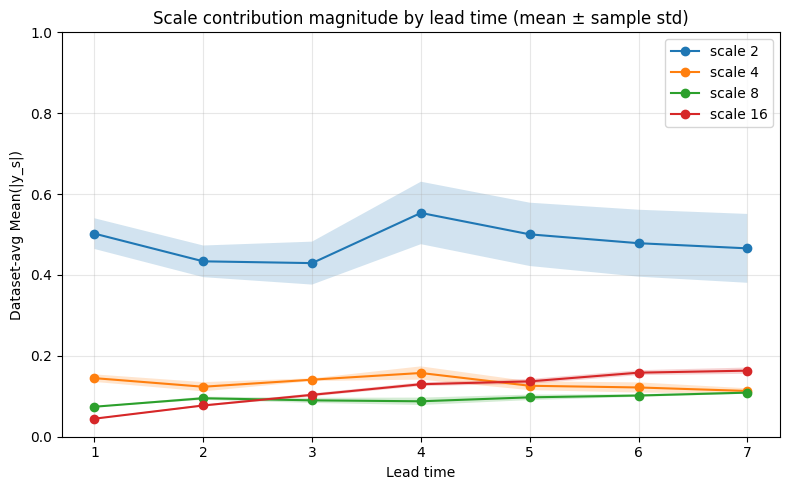

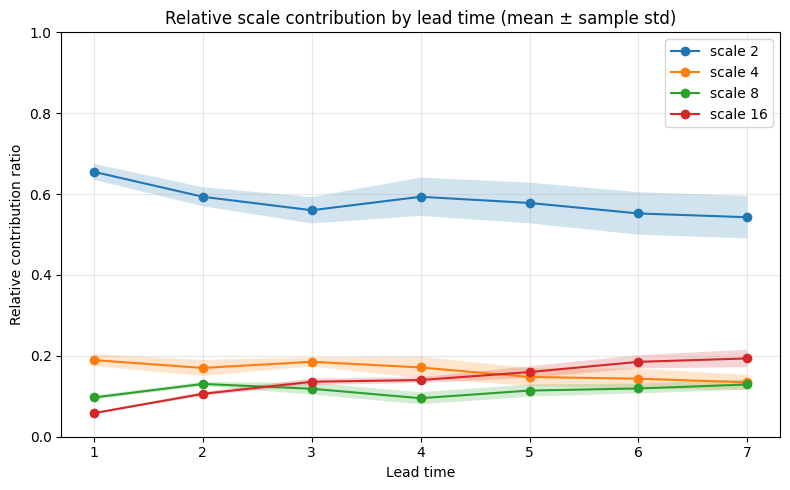

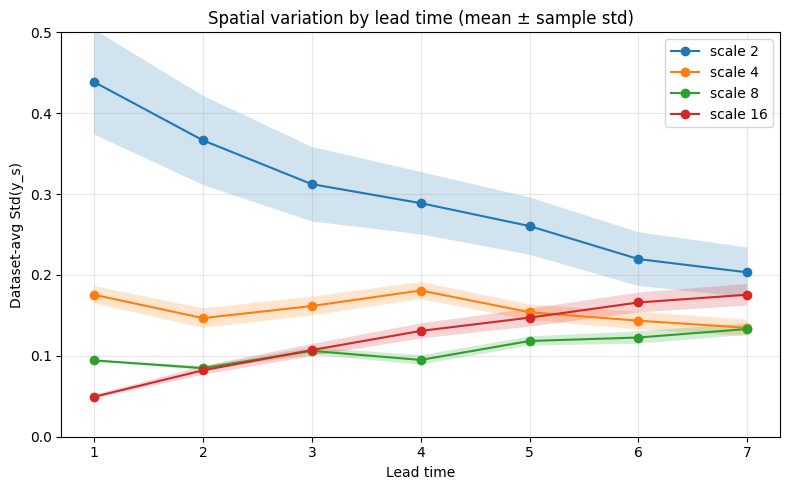

In [72]:
import numpy as np
import matplotlib.pyplot as plt

def plot_dataset_scale_contribution_by_lead_with_band(interpret):
    scales = sorted(interpret["scale_outputs"].keys())
    arr0 = interpret["scale_outputs"][scales[0]]
    n_samples, lead_count = arr0.shape[0], arr0.shape[1]
    leads = np.arange(1, lead_count + 1)

    mean_abs_mean_dict = {s: [] for s in scales}
    mean_abs_std_dict  = {s: [] for s in scales}

    std_mean_dict = {s: [] for s in scales}
    std_std_dict  = {s: [] for s in scales}

    ratio_mean_dict = {s: [] for s in scales}
    ratio_std_dict  = {s: [] for s in scales}

    for lead_idx in range(lead_count):
        per_scale_sample_mean_abs = []

        for s in scales:
            y = interpret["scale_outputs"][s][:, lead_idx, 0]   # (N, H, W)
            if hasattr(y, "detach"):
                y = y.detach().cpu().numpy()

            # sample별 mean(abs(.))
            sample_mean_abs = np.mean(np.abs(y), axis=(1, 2))   # (N,)
            # sample별 std(.)
            sample_std = np.std(y, axis=(1, 2))                 # (N,)

            mean_abs_mean_dict[s].append(sample_mean_abs.mean())
            mean_abs_std_dict[s].append(sample_mean_abs.std())

            std_mean_dict[s].append(sample_std.mean())
            std_std_dict[s].append(sample_std.std())

            per_scale_sample_mean_abs.append(sample_mean_abs)

        # sample별 ratio 계산 후 평균/표준편차
        per_scale_sample_mean_abs = np.stack(per_scale_sample_mean_abs, axis=1)  # (N, S)
        per_sample_ratios = per_scale_sample_mean_abs / (
            per_scale_sample_mean_abs.sum(axis=1, keepdims=True) + 1e-12
        )

        for i, s in enumerate(scales):
            ratio_mean_dict[s].append(per_sample_ratios[:, i].mean())
            ratio_std_dict[s].append(per_sample_ratios[:, i].std())

    # ---------------------------
    # 1) mean(abs(y_s)) + std band
    # ---------------------------
    plt.figure(figsize=(8, 5))
    for s in scales:
        y = np.array(mean_abs_mean_dict[s])
        e = np.array(mean_abs_std_dict[s])
        plt.plot(leads, y, marker='o', label=f'scale {s}')
        plt.fill_between(leads, y - e, y + e, alpha=0.2)
    plt.xlabel("Lead time")
    plt.ylabel("Dataset-avg Mean(|y_s|)")
    plt.title("Scale contribution magnitude by lead time (mean ± sample std)")
    plt.xticks(leads)
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # 2) ratio + std band
    # ---------------------------
    plt.figure(figsize=(8, 5))
    for s in scales:
        y = np.array(ratio_mean_dict[s])
        e = np.array(ratio_std_dict[s])
        plt.plot(leads, y, marker='o', label=f'scale {s}')
        plt.fill_between(leads, y - e, y + e, alpha=0.2)
    plt.xlabel("Lead time")
    plt.ylabel("Relative contribution ratio")
    plt.title("Relative scale contribution by lead time (mean ± sample std)")
    plt.xticks(leads)
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # 3) std(y_s) + std band
    # ---------------------------
    plt.figure(figsize=(8, 5))
    for s in scales:
        y = np.array(std_mean_dict[s])
        e = np.array(std_std_dict[s])
        plt.plot(leads, y, marker='o', label=f'scale {s}')
        plt.fill_between(leads, y - e, y + e, alpha=0.2)
    plt.xlabel("Lead time")
    plt.ylabel("Dataset-avg Std(y_s)")
    plt.title("Spatial variation by lead time (mean ± sample std)")
    plt.xticks(leads)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.ylim(0, 0.5)
    plt.show()

    return {
        "mean_abs_mean": mean_abs_mean_dict,
        "mean_abs_std": mean_abs_std_dict,
        "ratio_mean": ratio_mean_dict,
        "ratio_std": ratio_std_dict,
        "std_mean": std_mean_dict,
        "std_std": std_std_dict,
    }

stats = plot_dataset_scale_contribution_by_lead_with_band(interpret)

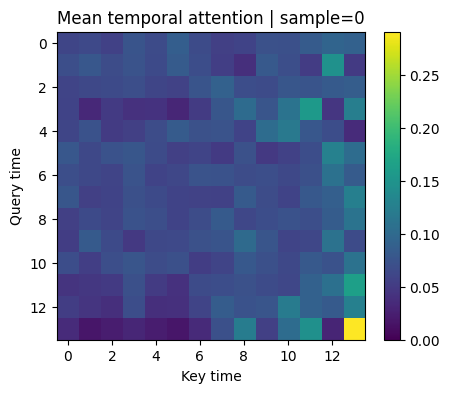

In [73]:
import numpy as np
import matplotlib.pyplot as plt

block_idx = max(interpret["temporal_attn"].keys())
attn_t = interpret["temporal_attn"][block_idx]

# attn_t shape이 (B, Ns, T, T)라고 가정
sample_idx = 0

mat = attn_t[sample_idx].mean(axis=0)   # (T, T)

plt.figure(figsize=(5, 4))
plt.imshow(mat, cmap="viridis", vmin=0, vmax=mat.max())
plt.title(f"Mean temporal attention | sample={sample_idx}")
plt.xlabel("Key time")
plt.ylabel("Query time")
plt.colorbar()
plt.show()

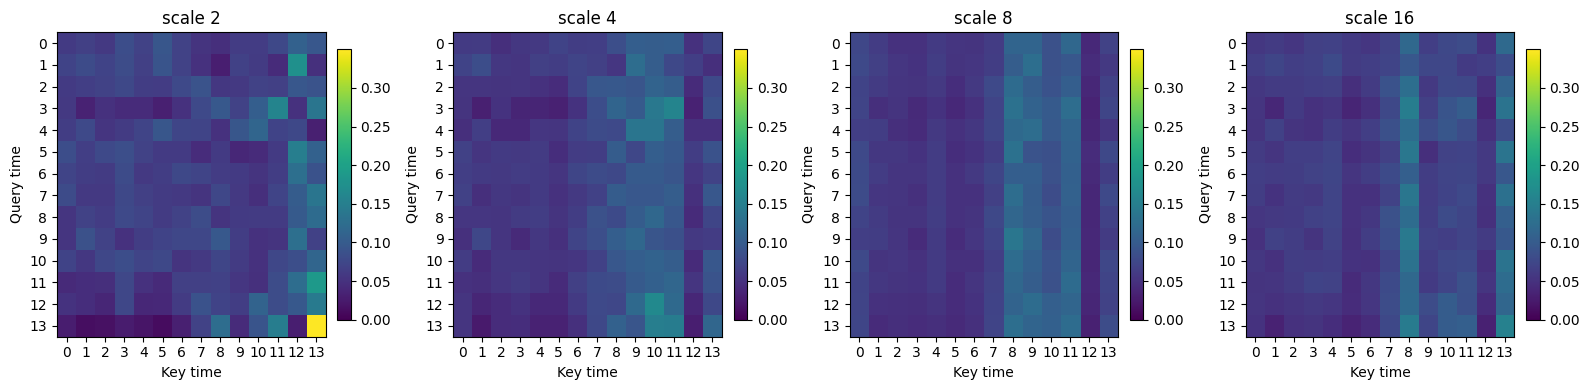

In [74]:
import numpy as np
import matplotlib.pyplot as plt

def get_scale_token_ranges(H=32, W=32, scales=(2, 4, 8, 16)):
    ranges = {}
    start = 0
    for s in scales:
        n = (H // s) * (W // s)
        ranges[s] = (start, start + n)
        start += n
    return ranges

ranges = get_scale_token_ranges(H=32, W=32, scales=(2, 4, 8, 16))

block_idx = max(interpret["temporal_attn"].keys())
attn_t = interpret["temporal_attn"][block_idx]   # (B, Ns, T, T)

sample_idx = 0
T = attn_t.shape[-2]
time_ticks = np.arange(T)

scales = sorted(ranges.keys())
mats = []

for s in scales:
    st, ed = ranges[s]
    mat = attn_t[sample_idx, st:ed].mean(axis=0)   # (T, T)
    mats.append(mat)

global_vmin = 0
global_vmax = max(mat.max() for mat in mats)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, s, mat in zip(axes, scales, mats):
    im = ax.imshow(
        mat,
        origin="upper",
        aspect="auto",
        cmap="viridis",
        vmin=global_vmin,
        vmax=global_vmax,
        extent=[-0.5, T - 0.5, T - 0.5, -0.5]
    )

    ax.set_title(f"scale {s}")
    ax.set_xlabel("Key time")
    ax.set_ylabel("Query time")
    ax.set_xticks(time_ticks)
    ax.set_yticks(time_ticks)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

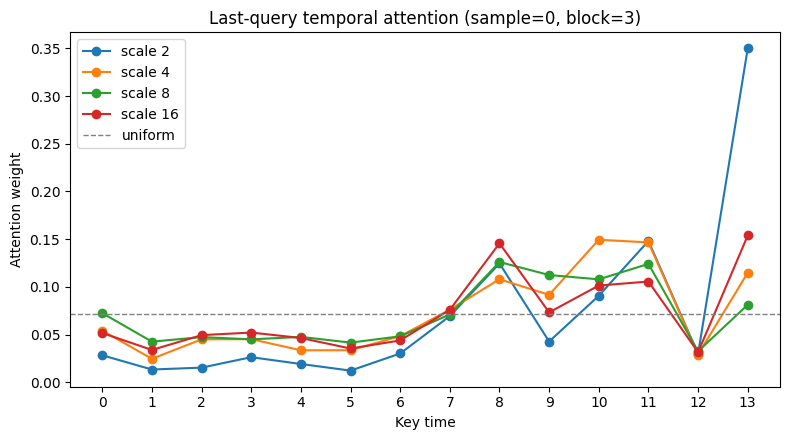

In [81]:
import numpy as np
import matplotlib.pyplot as plt

def get_scale_token_ranges(H=32, W=32, scales=(2, 4, 8, 16)):
    ranges = {}
    start = 0
    for s in scales:
        n = (H // s) * (W // s)
        ranges[s] = (start, start + n)
        start += n
    return ranges

ranges = get_scale_token_ranges(H=32, W=32, scales=(2, 4, 8, 16))

block_idx = max(interpret["temporal_attn"].keys())
attn_t = interpret["temporal_attn"][block_idx]   # (B, Ns, T, T)

sample_idx = 0
T = attn_t.shape[-1]
last_q = T - 1
scales = sorted(ranges.keys())

plt.figure(figsize=(8, 4.5))

for s in scales:
    st, ed = ranges[s]
    # scale 내부 token 평균 후 마지막 query row만 사용
    vec = attn_t[sample_idx, st:ed].mean(axis=0)[last_q]   # (T,)
    plt.plot(np.arange(T), vec, marker="o", label=f"scale {s}")

# uniform baseline
plt.axhline(1.0 / T, linestyle="--", linewidth=1, color="gray", label="uniform")

plt.xticks(np.arange(T))
plt.xlabel("Key time")
plt.ylabel("Attention weight")
plt.title(f"Last-query temporal attention (sample={sample_idx}, block={block_idx})")
plt.legend()
plt.tight_layout()

plt.show()

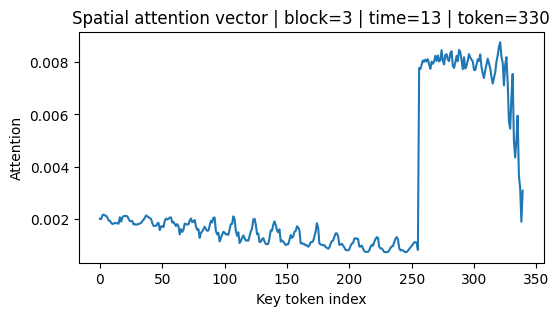

In [75]:

block_idx = max(interpret["spatial_attn"].keys())
attn_s = interpret["spatial_attn"][block_idx]

sample_idx = 0
time_idx = cfg["input_len"] - 1
query_token_idx = 330

vec = attn_s[sample_idx, time_idx, query_token_idx].numpy()

plt.figure(figsize=(6, 3))
plt.plot(vec)
plt.title(f"Spatial attention vector | block={block_idx} | time={time_idx} | token={query_token_idx}")
plt.xlabel("Key token index")
plt.ylabel("Attention")
plt.show()


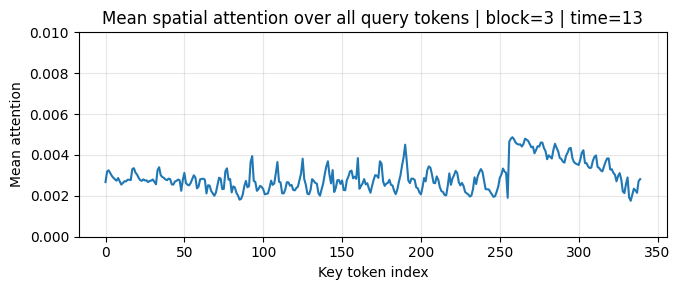

In [76]:
import numpy as np
import matplotlib.pyplot as plt

block_idx = max(interpret["spatial_attn"].keys())
attn_s = interpret["spatial_attn"][block_idx]

sample_idx = 0
time_idx = cfg["input_len"] - 1

# attn_s shape 가정: (B, T, Nq, Nk)
A = attn_s[sample_idx, time_idx]   # (Nq, Nk)
if hasattr(A, "detach"):
    A = A.detach().cpu().numpy()

mean_vec = A.mean(axis=0)          # (Nk,)

plt.figure(figsize=(7, 3))
plt.plot(mean_vec)
plt.title(f"Mean spatial attention over all query tokens | block={block_idx} | time={time_idx}")
plt.xlabel("Key token index")
plt.ylabel("Mean attention")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0,0.01)
plt.show()

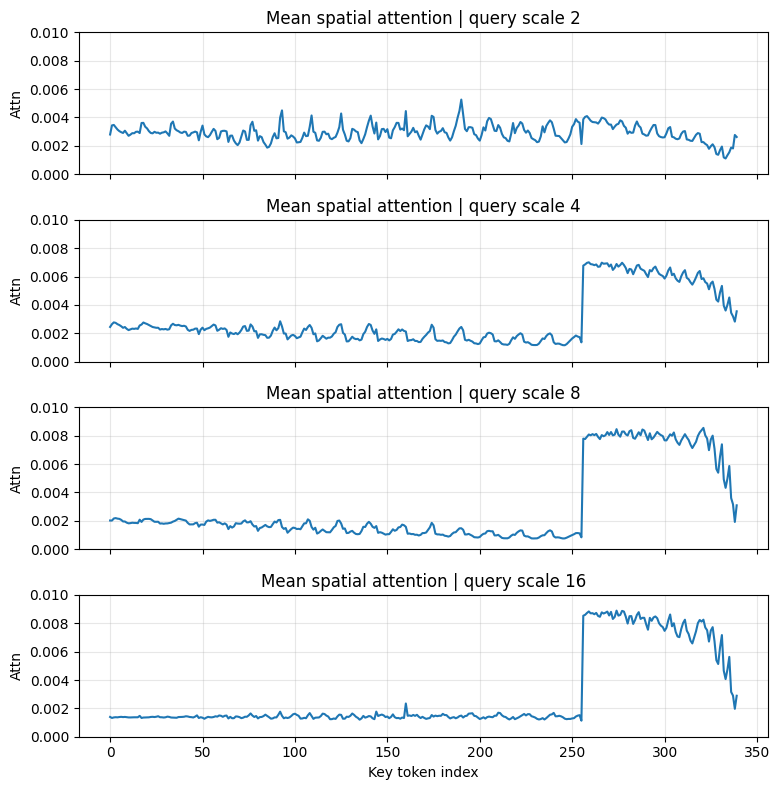

In [77]:
import numpy as np
import matplotlib.pyplot as plt

def get_scale_token_ranges(H=32, W=32, scales=(2, 4, 8, 16)):
    ranges = {}
    start = 0
    for s in scales:
        n = (H // s) * (W // s)
        ranges[s] = (start, start + n)   # [start, end)
        start += n
    return ranges

block_idx = max(interpret["spatial_attn"].keys())
attn_s = interpret["spatial_attn"][block_idx]

sample_idx = 0
time_idx = cfg["input_len"] - 1

A = attn_s[sample_idx, time_idx]   # (Nq, Nk)
if hasattr(A, "detach"):
    A = A.detach().cpu().numpy()

ranges = get_scale_token_ranges(H=32, W=32, scales=(2, 4, 8, 16))

fig, axes = plt.subplots(len(ranges), 1, figsize=(8, 8), sharex=True)

for ax, s in zip(axes, sorted(ranges.keys())):
    st, ed = ranges[s]
    mean_vec_scale = A[st:ed].mean(axis=0)   # scale s query들 평균 -> (Nk,)

    ax.plot(mean_vec_scale)
    ax.set_title(f"Mean spatial attention | query scale {s}")
    ax.set_ylabel("Attn")
    ax.set_ylim(0, 0.01)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Key token index")
plt.tight_layout()
plt.show()

In [78]:
import numpy as np
import matplotlib.pyplot as plt

def get_scale_token_ranges(H=32, W=32, scales=(2, 4, 8, 16)):
    ranges = {}
    start = 0
    for s in scales:
        n = (H // s) * (W // s)
        ranges[s] = (start, start + n)   # [start, end)
        start += n
    return ranges


def analyze_dataset_spatial_attention(
    interpret,
    cfg,
    H=32,
    W=32,
    scales=(2, 4, 8, 16),
    block_idx=None,
    time_idx=None,
):
    if block_idx is None:
        block_idx = max(interpret["spatial_attn"].keys())
    if time_idx is None:
        time_idx = cfg["input_len"] - 1

    attn_s = interpret["spatial_attn"][block_idx]

    if hasattr(attn_s, "detach"):
        attn_s = attn_s.detach().cpu().numpy()

    # expected shape: (B, T, Nq, Nk)
    print("spatial_attn shape:", attn_s.shape)

    A = attn_s[:, time_idx]   # (B, Nq, Nk)
    Bsz, Nq, Nk = A.shape

    ranges = get_scale_token_ranges(H=H, W=W, scales=scales)

    # --------------------------------------------------
    # 1) Dataset-average over all query tokens
    # --------------------------------------------------
    mean_vec_all = A.mean(axis=(0, 1))   # average over batch and query tokens -> (Nk,)

    plt.figure(figsize=(8, 3))
    plt.plot(mean_vec_all)
    plt.title(f"Dataset-avg spatial attention over all query tokens | block={block_idx} | time={time_idx}")
    plt.xlabel("Key token index")
    plt.ylabel("Mean attention")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.ylim(0, 0.01)
    plt.show()

    # --------------------------------------------------
    # 2) Dataset-average vector for each query scale
    # --------------------------------------------------
    fig, axes = plt.subplots(len(scales), 1, figsize=(8, 2.7 * len(scales)), sharex=True)
    if len(scales) == 1:
        axes = [axes]

    scale_query_mean_vectors = {}

    for ax, qs in zip(axes, scales):
        qst, qed = ranges[qs]
        vec = A[:, qst:qed, :].mean(axis=(0, 1))   # average over batch and query tokens of this scale
        scale_query_mean_vectors[qs] = vec

        ax.plot(vec)
        ax.set_title(f"Dataset-avg spatial attention | query scale {qs}")
        ax.set_ylabel("Attn")
        ax.set_ylim(0, 0.01)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Key token index")
    plt.tight_layout()

    plt.show()

    return {
        "block_idx": block_idx,
        "time_idx": time_idx,
        "ranges": ranges,
        "mean_vec_all": mean_vec_all,
        "scale_query_mean_vectors": scale_query_mean_vectors,
    }

spatial_attn shape: (30, 14, 340, 340)


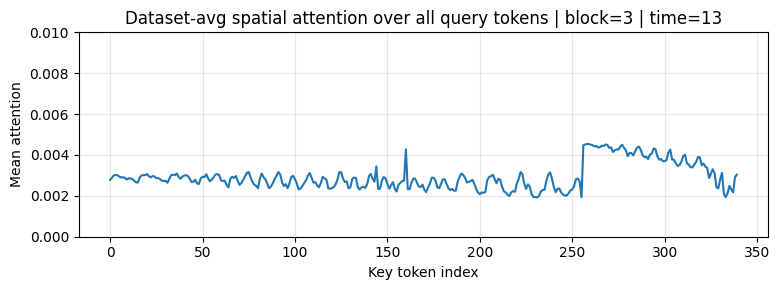

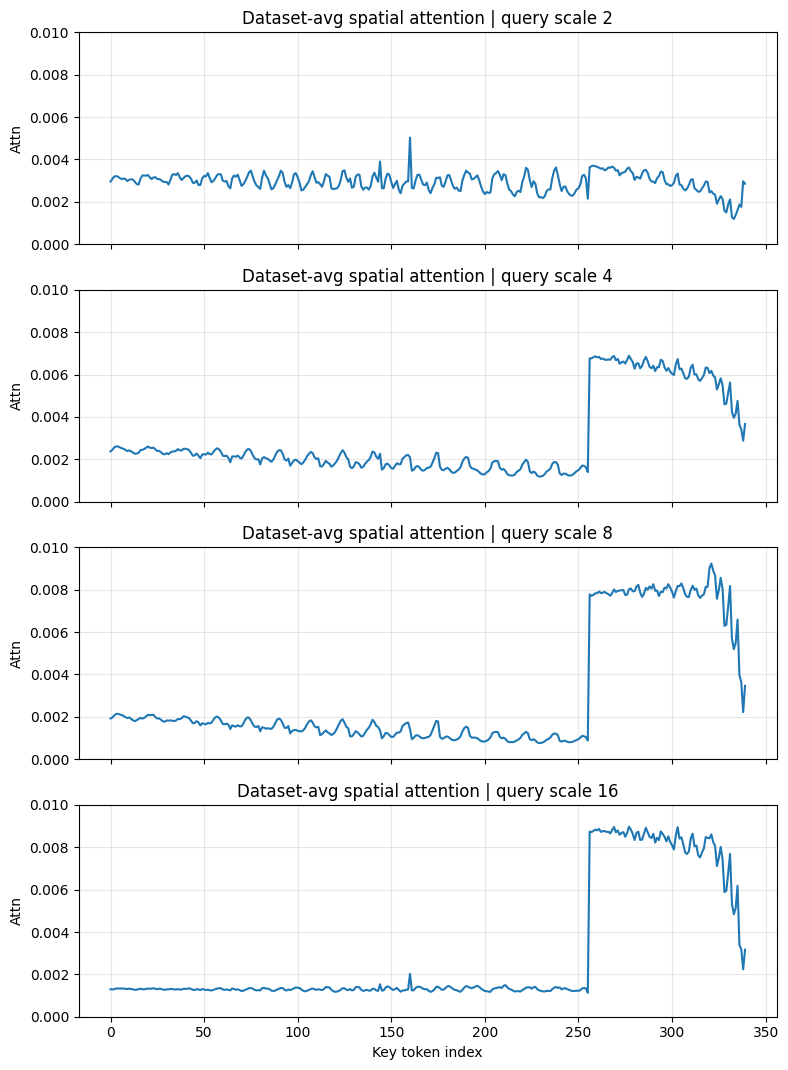

In [79]:
stats_spatial = analyze_dataset_spatial_attention(
    interpret,
    cfg,
    H=32,
    W=32,
    scales=(2, 4, 8, 16),
)

/tmp/ipykernel_4171448/1187080909.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


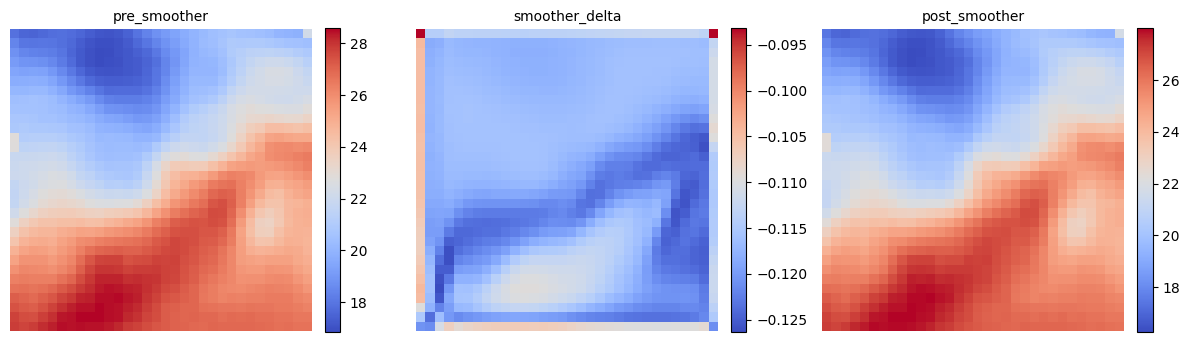

In [80]:

sample_idx = 0
lead_idx = 0

pre = denorm(interpret["pre_smoother"][sample_idx, lead_idx, 0], mean, std)
delta = interpret["smoother_delta"][sample_idx, lead_idx, 0].numpy()
post = denorm(interpret["post_smoother"][sample_idx, lead_idx, 0], mean, std)

show_sst_grid(
    [pre, delta, post],
    titles=["pre_smoother", "smoother_delta", "post_smoother"],
    ncols=3,
    figsize=(12, 4),
)
